# Activity 1: Sky Pixel Detection

**Goal:** load a landscape photo, find all sky-coloured pixels (blue tones + white clouds), highlight them, and report what percentage of the image is sky.

**Plan in 5 steps:**
1. Load the image and understand its structure (pixels as numbers)
2. Understand why we switch from BGR to HSV colour space
3. Convert to HSV and inspect pixel values
4. Define colour ranges for sky, build a mask, count the pixels
5. Colour the sky bright green and visualise the result

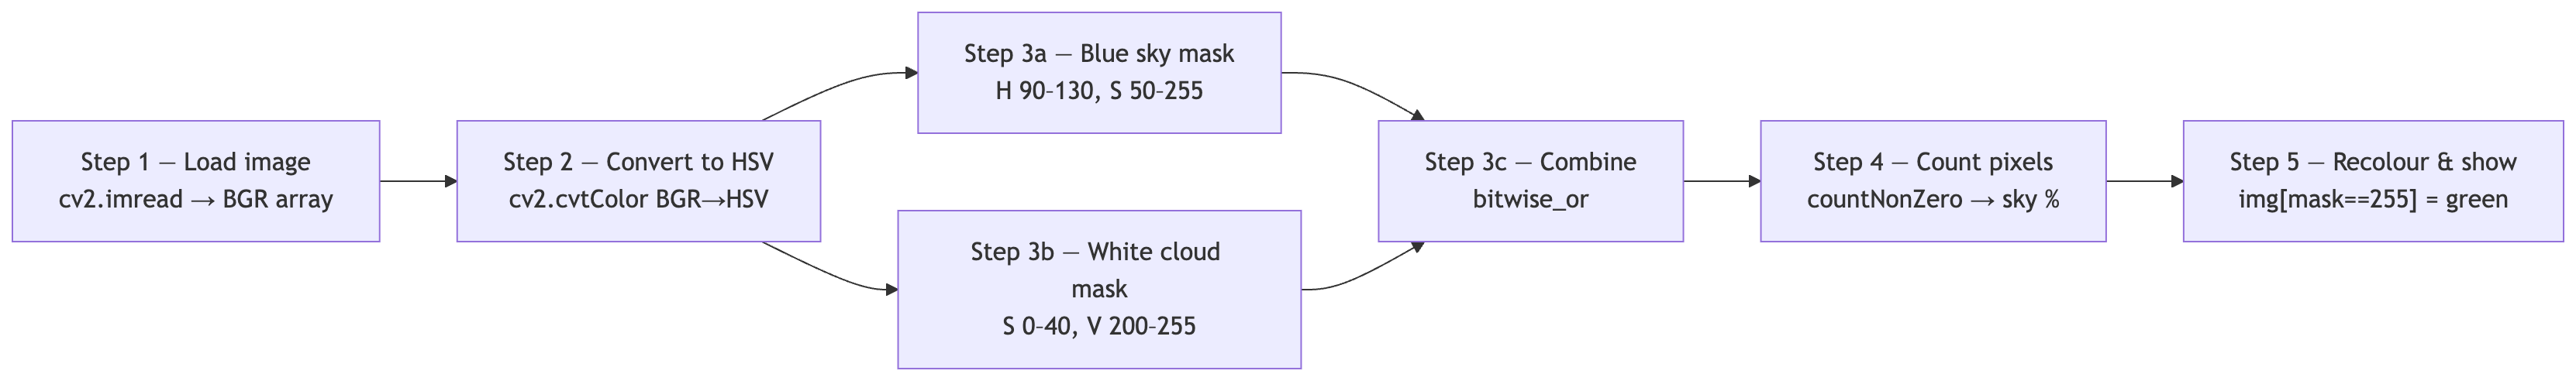

In [11]:
from IPython.display import Image, display
display(Image(filename='A1Pipeline.png'))

## Step 1: Load the image and understand its structure

An image is nothing more than a **3D NumPy array** with shape `(height, width, 3)`.

Think of it as a grid of rows and columns, and at each position there is a pixel. Each pixel stores **three numbers** — one per colour channel. OpenCV uses **BGR order** (not the RGB you might expect):

```
img[row, col]  →  [Blue, Green, Red]   each value: 0 (none) … 255 (full intensity)
```

So `img[0, 0]` gives you the top-left pixel.  
`img[100, 200]` gives you the pixel 100 rows down and 200 columns across.

Image size  : 750 × 485 pixels
Channels    : 3  (index 0=Blue, 1=Green, 2=Red  — OpenCV uses BGR, not RGB)
Total pixels: 363,750

Top-left pixel → B=147, G=73, R=1


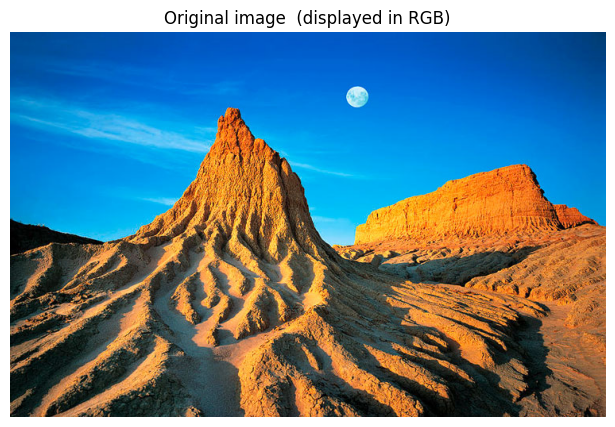

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image — cv2.imread returns a (height, width, 3) NumPy array in BGR format
img_bgr = cv2.imread('scene.jpg')

if img_bgr is None:
    raise FileNotFoundError(
        "scene.jpg not found. Save any outdoor landscape photo as 'scene.jpg' "
        "in the same folder as this notebook, then re-run."
    )

height, width, channels = img_bgr.shape
print(f'Image size  : {width} × {height} pixels')
print(f'Channels    : {channels}  (index 0=Blue, 1=Green, 2=Red  — OpenCV uses BGR, not RGB)')
print(f'Total pixels: {height * width:,}')
print()

# Inspect one pixel — row 0, column 0 (top-left corner)
pixel = img_bgr[0, 0]
print(f'Top-left pixel → B={pixel[0]}, G={pixel[1]}, R={pixel[2]}')

# Show the image — matplotlib expects RGB, so flip channels just for display
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title('Original image  (displayed in RGB)')
plt.axis('off')
plt.show()

## Step 2: Why switch from BGR to HSV?

You might think: *"sky is blue, just find pixels where B is high."*  
The problem is that **lighting changes everything**:

- A bright white cloud → `B=255, G=255, R=255` (all channels equal — looks white, not blue)
- A dim evening sky → `B=80, G=60, R=50` (low blue, no obvious rule)

**HSV** separates colour from brightness, making thresholding far more robust:

| Channel | Meaning | OpenCV range |
|---|---|---|
| **H**ue | The pure colour (which colour on the rainbow) | 0–179 |
| **S**aturation | How vivid vs grey (0 = grey, 255 = vivid) | 0–255 |
| **V**alue | Brightness (0 = black, 255 = bright) | 0–255 |

- **Blue sky** → H ≈ 90–130, moderate-high S, moderate-high V
- **White clouds** → any H, very low S (near-grey), high V

This lets us write two simple rules that work regardless of lighting.

In [13]:
# Convert from BGR to HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Compare the SAME pixel in both colour spaces
row, col = 10, 10   # try a pixel you know is in the sky area
bgr_px = img_bgr[row, col]
hsv_px = img_hsv[row, col]

print(f'Pixel [{row},{col}] in BGR → B={bgr_px[0]:3d}, G={bgr_px[1]:3d}, R={bgr_px[2]:3d}')
print(f'Pixel [{row},{col}] in HSV → H={hsv_px[0]:3d}, S={hsv_px[1]:3d}, V={hsv_px[2]:3d}')
print()
print('Tip: change row/col to sample a sky pixel and a non-sky pixel')
print('     then observe how H, S, V differ between them.')

Pixel [10,10] in BGR → B=148, G= 76, R=  0
Pixel [10,10] in HSV → H=105, S=255, V=148

Tip: change row/col to sample a sky pixel and a non-sky pixel
     then observe how H, S, V differ between them.


## Step 3: Define the sky colour ranges and build the mask

Sky has **two distinct appearances** we need to catch separately:

| Sky type | Hue (H) | Saturation (S) | Value (V) |
|---|---|---|---|
| **Clear blue sky** | 90–130 (blue-cyan zone) | 50–255 (vivid) | 50–255 (not too dark) |
| **White clouds / hazy sky** | 0–179 (any — it's grey/white) | 0–40 (near-grey) | 200–255 (bright) |

`cv2.inRange(hsv_image, lower, upper)` returns a **binary mask**:
- **255 (white)** → pixel is inside the range → it IS sky
- **0 (black)** → pixel is outside the range → it is NOT sky

We then combine both masks with `cv2.bitwise_or()` - a pixel qualifies as sky if it matches **either** range.

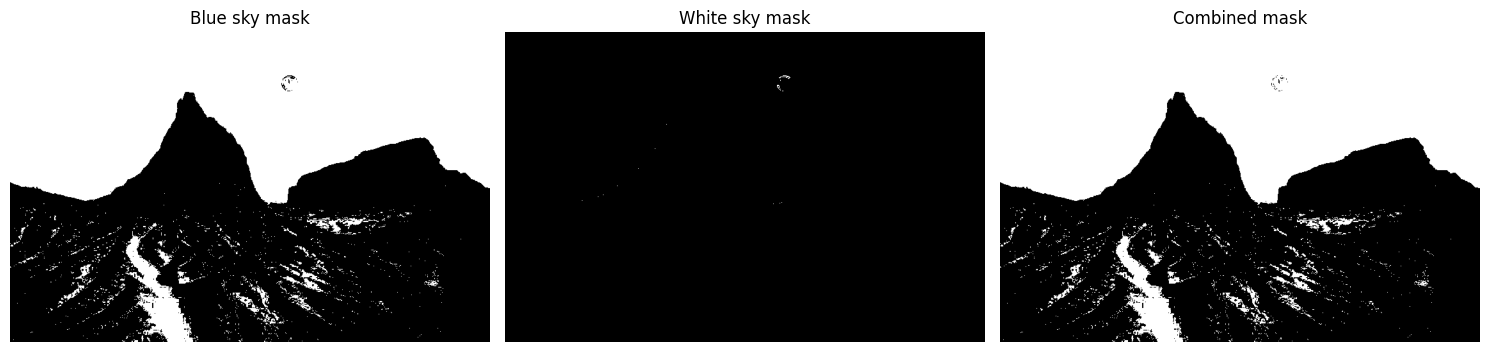

White pixels = sky  |  Black pixels = not sky


In [14]:
# --- Blue sky range (clear, vivid blue) ---
lower_blue = np.array([90,  50,  50])    # H, S, V  lower bounds
upper_blue = np.array([130, 255, 255])   # H, S, V  upper bounds
mask_blue  = cv2.inRange(img_hsv, lower_blue, upper_blue)

# --- White / hazy sky range (clouds, pale sky) ---
# Any hue (0-179), near-zero saturation, high brightness
lower_white = np.array([0,   0,  200])
upper_white = np.array([179, 40, 255])
mask_white  = cv2.inRange(img_hsv, lower_white, upper_white)

# Combine: a pixel is "sky" if it matches EITHER range
sky_mask = cv2.bitwise_or(mask_blue, mask_white)

# Visualise all three masks side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(mask_blue,  cmap='gray'); axes[0].set_title('Blue sky mask');  axes[0].axis('off')
axes[1].imshow(mask_white, cmap='gray'); axes[1].set_title('White sky mask'); axes[1].axis('off')
axes[2].imshow(sky_mask,   cmap='gray'); axes[2].set_title('Combined mask');  axes[2].axis('off')
plt.tight_layout()
plt.show()
print('White pixels = sky  |  Black pixels = not sky')

## Step 4: Count the sky pixels

`cv2.countNonZero(mask)` counts every pixel in the mask that equals `255` - those are our sky pixels.

Dividing by total pixels × 100 gives the percentage of the image that is sky.

```
sky %  =  (sky pixels / total pixels)  ×  100
```

In [15]:
total_pixels = height * width
sky_pixels   = cv2.countNonZero(sky_mask)  # counts pixels where mask == 255
not_sky      = total_pixels - sky_pixels
pct_sky      = sky_pixels / total_pixels * 100

print(f'Total pixels  : {total_pixels:>10,}')
print(f'Sky pixels    : {sky_pixels:>10,}  ({pct_sky:.1f}%)')
print(f'Non-sky pixels: {not_sky:>10,}  ({100 - pct_sky:.1f}%)')

Total pixels  :    363,750
Sky pixels    :    169,465  (46.6%)
Non-sky pixels:    194,285  (53.4%)


## Step 5: Colour the sky and visualise

Now we'll apply the mask back onto the original image to **highlight** where sky was detected.

We'll paint those pixels bright **green** - an unmistakable color that won't appear naturally in a sky photo, so we can instantly see what the algorithm found.

Two key operations:
- `img_bgr.copy()` - duplicates the array so we never destroy the original
- `result[sky_mask == 255] = [0, 255, 0]` - NumPy boolean indexing: select every pixel where the mask is white (255 = sky), set its BGR value to green

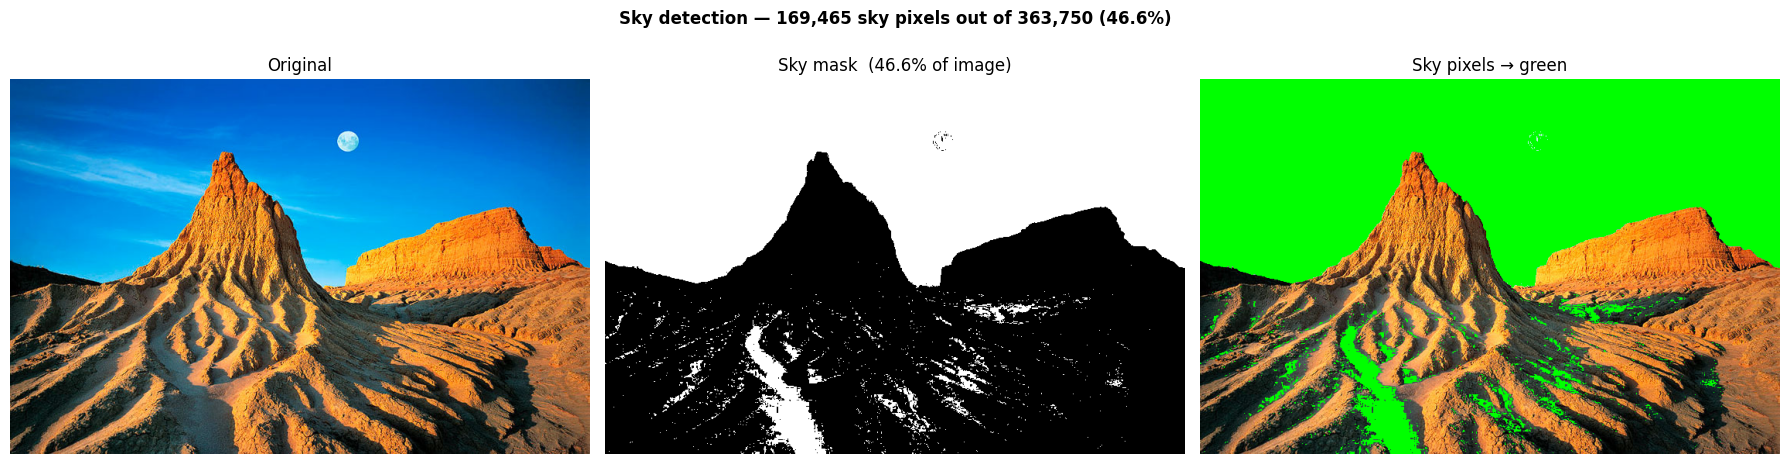

In [16]:
# Create a copy so we don't overwrite the original
result = img_bgr.copy()

# Paint all sky pixels bright green [B=0, G=255, R=0] in BGR
# img[mask == 255] uses NumPy boolean indexing:
# it selects ONLY the pixels where the mask is 255 (sky) and recolours them
result[sky_mask == 255] = [0, 255, 0]

# Display original | mask | result side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(sky_mask, cmap='gray')
axes[1].set_title(f'Sky mask  ({pct_sky:.1f}% of image)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[2].set_title('Sky pixels → green')
axes[2].axis('off')

plt.suptitle(
    f'Sky detection — {sky_pixels:,} sky pixels out of {total_pixels:,} ({pct_sky:.1f}%)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()